# Phase 4: Extending to Three Dimensions

Every phase so far has lived in a flat, 2D orbital plane. Real orbits don't — a satellite's path is tilted in three-dimensional space, and a telescope on the ground doesn't see a 2D map of that path. It sees a flat image: a single 2D pixel position representing something that's actually moving through 3D.

This phase rebuilds the full pipeline — physics-informed prediction, vision-based observation, and Kalman filter fusion — in 3D, and in doing so runs into a problem the earlier phases didn't have to face:

**A camera image only tells you a direction, not a distance.**

Point a telescope at a satellite, and the image tells you *which way* to look — but not *how far away* the satellite is along that line of sight. Two very different 3D positions can produce the exact same pixel in the image, as long as they're both along the same ray from the camera.

This is where the project's core idea — physics and vision correcting each other — gets to prove itself for real. The vision model will supply *direction* (bearing), and the physics-informed model will supply a prior on *distance* (depth) from its own trajectory prediction. The Extended Kalman Filter is what reconciles the two into a single 3D position estimate — and this time, the "Extended" part of the EKF is doing genuine work, because projecting a 3D point into a 2D image is a nonlinear operation with no shortcut around it.

![Depth ambiguity: two different 3D points can land on the same pixel](../images/depth_ambiguity_concept.png)

## Step 1: Simulating a Real 3D Orbit

In 2D, an orbit was fully described by position (x, y) and velocity (vx, vy). In 3D, we add a z-axis, and the orbit no longer has to lie flat — it can be *inclined*, tilted at an angle relative to our chosen reference plane, the way real satellite orbits actually are.

The physics doesn't get more complicated — it's still Newton's law of gravitation, just with one more dimension. The interesting part is that we'll deliberately choose an inclined, tilted orbit (not a flat one) so the 3D visualizations actually look three-dimensional, and so the depth-ambiguity problem from the intro is real and not just theoretical.

In [2]:
import numpy as np          # numerical arrays and math (sqrt, linspace, etc.)
import torch                # building and training the 3D PINN
import torch.nn as nn       # neural network layers
from torch.autograd.functional import jacobian   # EKF Jacobian computation later in this notebook
import matplotlib.pyplot as plt                  # 2D plotting
from mpl_toolkits.mplot3d import Axes3D          # enables 3D plotting
from scipy.integrate import solve_ivp            # numerically solves the 3D orbital equations

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Numerically integrates the 3D two-body problem to produce a trusted ground-truth orbit
from scipy.integrate import solve_ivp

def two_body_3d(t, state, GM=1.0):
    x, y, z, vx, vy, vz = state
    r = np.sqrt(x**2 + y**2 + z**2)
    ax = -GM * x / r**3
    ay = -GM * y / r**3
    az = -GM * z / r**3
    return [vx, vy, vz, ax, ay, az]

GM = 1.0

# Initial state: deliberately tilted out of the xy-plane so the orbit is genuinely 3D
initial_state_3d = [1.0, 0.0, 0.0, 0.0, 0.7, 0.3]

t_span = (0, 20)
t_eval = np.linspace(*t_span, 2000)

solution_3d = solve_ivp(
    two_body_3d, t_span, initial_state_3d, t_eval=t_eval,
    args=(GM,), method="DOP853", rtol=1e-10, atol=1e-10
)

x_true_3d, y_true_3d, z_true_3d = solution_3d.y[0], solution_3d.y[1], solution_3d.y[2]

print(f"3D orbit simulated: {len(t_eval)} points over t in {t_span}")
print(f"z ranges from {z_true_3d.min():.3f} to {z_true_3d.max():.3f} — confirms the orbit is genuinely tilted out of plane")

3D orbit simulated: 2000 points over t in (0, 20)
z ranges from -0.252 to 0.252 — confirms the orbit is genuinely tilted out of plane


## Visualizing the 3D Orbit

Here's what that tilted orbit actually looks like in three dimensions. The plot is interactive — in VS Code / Jupyter, you can click and drag to rotate it and see the tilt from different angles.

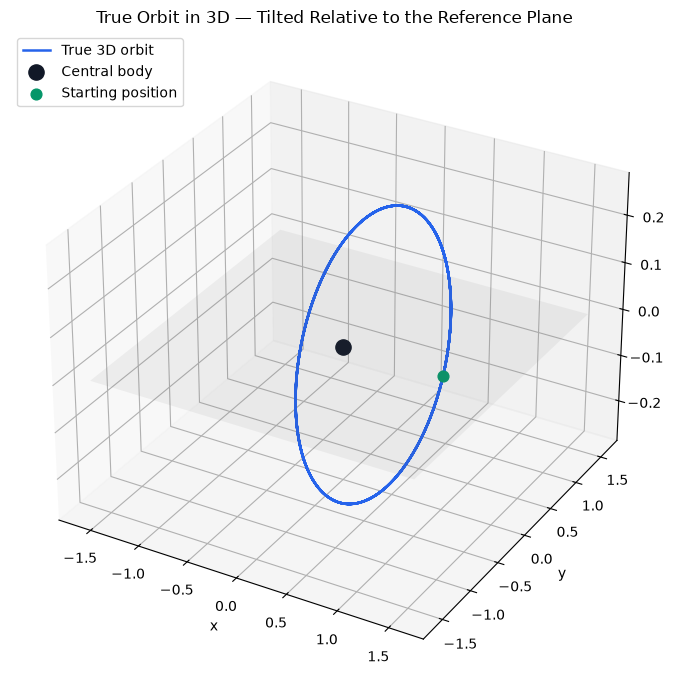

In [4]:
# Renders the true 3D orbit as a rotatable 3D plot
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x_true_3d, y_true_3d, z_true_3d, color="#2563eb", linewidth=1.8, label="True 3D orbit")
ax.scatter([0], [0], [0], color="#111827", s=120, label="Central body")
ax.scatter([x_true_3d[0]], [y_true_3d[0]], [z_true_3d[0]], color="#059669", s=60, label="Starting position")

# Draw the flat xy-plane as a faint reference, so the tilt is visually obvious
plane_range = 1.6
xx, yy = np.meshgrid(np.linspace(-plane_range, plane_range, 2), np.linspace(-plane_range, plane_range, 2))
ax.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.08, color="gray")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("True Orbit in 3D — Tilted Relative to the Reference Plane")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Step 2: A Physics-Informed Network for 3D Position

The PINN architecture barely changes — same feedforward network, same idea of learning position as a function of time. The only structural change is the output layer: instead of predicting (x, y), it now predicts (x, y, z).

The physics loss changes more substantively. Newton's law of gravitation now has three components instead of two. And the conservation constraints that rescued Phase 1 from its escaping-trajectory bug need a 3D upgrade too:

- **Energy** is still a single number — that doesn't change in 3D.
- **Angular momentum**, however, becomes a *vector* in 3D: **L** = **r** × **v** (position crossed with velocity). It points perpendicular to the orbital plane, and for an orbit to stay stable, *all three of its components* must stay constant — not just one number, like in the 2D case.

In [5]:
# Defines the 3D PINN: same architecture as Phase 1, but now outputs (x, y, z) instead of (x, y)
class PINN3D(nn.Module):
    def __init__(self, hidden_dim=64, n_hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, 3)]  # outputs x, y, z
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return self.net(t)

## Step 3: The 3D Physics-Informed Loss

This is the same three-part loss as Phase 1 — a physics residual, an initial-condition match, and a conservation constraint — just extended into the third dimension. The angular momentum part is the most different: instead of one cross-product term, it's now a full 3D cross product, giving three components that each need to stay constant.

In [6]:
# Computes the 3D physics-informed loss: Newton's law residual, initial-condition match,
# and conservation of energy + the full 3D angular momentum vector
def physics_informed_loss_3d(model, t_collocation, t0, state0, GM=1.0):
    t_collocation = t_collocation.clone().requires_grad_(True)
    r_pred = model(t_collocation)
    x, y, z = r_pred[:, 0:1], r_pred[:, 1:2], r_pred[:, 2:3]

    vx = torch.autograd.grad(x, t_collocation, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    vy = torch.autograd.grad(y, t_collocation, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    vz = torch.autograd.grad(z, t_collocation, grad_outputs=torch.ones_like(z), create_graph=True)[0]

    ax = torch.autograd.grad(vx, t_collocation, grad_outputs=torch.ones_like(vx), create_graph=True)[0]
    ay = torch.autograd.grad(vy, t_collocation, grad_outputs=torch.ones_like(vy), create_graph=True)[0]
    az = torch.autograd.grad(vz, t_collocation, grad_outputs=torch.ones_like(vz), create_graph=True)[0]

    r = torch.sqrt(x**2 + y**2 + z**2 + 1e-8)

    residual_x = ax + GM * x / r**3
    residual_y = ay + GM * y / r**3
    residual_z = az + GM * z / r**3
    physics_loss = torch.mean(residual_x**2 + residual_y**2 + residual_z**2)

    # ---- Conservation loss: energy (scalar) + angular momentum (now a 3D vector) ----
    x0_true, y0_true, z0_true, vx0_true, vy0_true, vz0_true = state0
    r0_true = np.sqrt(x0_true**2 + y0_true**2 + z0_true**2)
    E_true = 0.5 * (vx0_true**2 + vy0_true**2 + vz0_true**2) - GM / r0_true
    Lx_true = y0_true * vz0_true - z0_true * vy0_true
    Ly_true = z0_true * vx0_true - x0_true * vz0_true
    Lz_true = x0_true * vy0_true - y0_true * vx0_true

    E_pred = 0.5 * (vx**2 + vy**2 + vz**2) - GM / r
    Lx_pred = y * vz - z * vy
    Ly_pred = z * vx - x * vz
    Lz_pred = x * vy - y * vx

    conservation_loss = (
        torch.mean((E_pred - E_true)**2) +
        torch.mean((Lx_pred - Lx_true)**2) +
        torch.mean((Ly_pred - Ly_true)**2) +
        torch.mean((Lz_pred - Lz_true)**2)
    )

    # ---- Initial condition loss ----
    t0 = t0.clone().requires_grad_(True)
    r0_pred = model(t0)
    x0_pred, y0_pred, z0_pred = r0_pred[:, 0:1], r0_pred[:, 1:2], r0_pred[:, 2:3]

    vx0_pred = torch.autograd.grad(x0_pred, t0, grad_outputs=torch.ones_like(x0_pred), create_graph=True)[0]
    vy0_pred = torch.autograd.grad(y0_pred, t0, grad_outputs=torch.ones_like(y0_pred), create_graph=True)[0]
    vz0_pred = torch.autograd.grad(z0_pred, t0, grad_outputs=torch.ones_like(z0_pred), create_graph=True)[0]

    ic_loss = ((x0_pred - x0_true)**2 + (y0_pred - y0_true)**2 + (z0_pred - z0_true)**2 +
               (vx0_pred - vx0_true)**2 + (vy0_pred - vy0_true)**2 + (vz0_pred - vz0_true)**2).mean()

    return physics_loss, ic_loss, conservation_loss

## Step 4: Curriculum Training

Same proven strategy as Phase 1 — train on a short time window first, then progressively extend it. This is what let the network build an accurate short-term picture before being asked to extrapolate over many orbits, and it's what actually fixed the escaping-trajectory problem back in Notebook 1.

In [7]:
# Trains the 3D PINN using curriculum learning: progressively widening time windows,
# with energy + angular-momentum conservation terms keeping the orbit physically stable
pinn_3d = PINN3D(hidden_dim=64, n_hidden_layers=4).to(device)
optimizer = torch.optim.Adam(pinn_3d.parameters(), lr=1e-3)

t0 = torch.tensor([[0.0]], device=device)
state0_3d = initial_state_3d  # [x0, y0, z0, vx0, vy0, vz0]

milestones = [4, 8, 12, 16, 20]
epochs_per_stage = 8000
ic_weight = 10.0
conservation_weight = 10.0
loss_history_3d = []

for stage, t_max in enumerate(milestones):
    print(f"--- Stage {stage+1}/{len(milestones)}: training on t in [0, {t_max}] ---")
    for epoch in range(epochs_per_stage):
        optimizer.zero_grad()
        t_colloc = torch.rand((500, 1), device=device) * t_max
        physics_loss, ic_loss, conservation_loss = physics_informed_loss_3d(
            pinn_3d, t_colloc, t0, state0_3d, GM=GM
        )
        loss = physics_loss + ic_weight * ic_loss + conservation_weight * conservation_loss
        loss.backward()
        optimizer.step()
        loss_history_3d.append(loss.item())
        if epoch % 4000 == 0:
            print(f"  Epoch {epoch:5d} | Total: {loss.item():.6f} | Physics: {physics_loss.item():.6f} "
                  f"| IC: {ic_loss.item():.6f} | Conservation: {conservation_loss.item():.6f}")

print("3D curriculum training complete.")

--- Stage 1/5: training on t in [0, 4] ---
  Epoch     0 | Total: 3502.615234 | Physics: 3034.198486 | IC: 1.689913 | Conservation: 45.151764
  Epoch  4000 | Total: 0.210072 | Physics: 0.158652 | IC: 0.000364 | Conservation: 0.004778
--- Stage 2/5: training on t in [0, 8] ---
  Epoch     0 | Total: 4.948063 | Physics: 1.240240 | IC: 0.000284 | Conservation: 0.370499
  Epoch  4000 | Total: 0.136225 | Physics: 0.113411 | IC: 0.000121 | Conservation: 0.002160
--- Stage 3/5: training on t in [0, 12] ---
  Epoch     0 | Total: 5.504478 | Physics: 1.952643 | IC: 0.000123 | Conservation: 0.355060
  Epoch  4000 | Total: 0.171988 | Physics: 0.132980 | IC: 0.000038 | Conservation: 0.003862
--- Stage 4/5: training on t in [0, 16] ---
  Epoch     0 | Total: 1.847709 | Physics: 0.527314 | IC: 0.000025 | Conservation: 0.132014
  Epoch  4000 | Total: 0.158980 | Physics: 0.128201 | IC: 0.000053 | Conservation: 0.003025
--- Stage 5/5: training on t in [0, 20] ---
  Epoch     0 | Total: 3.087116 | Physi

## Step 5: Visualizing the 3D PINN's Predicted Orbit

Time to see whether the conservation-law approach that saved Phase 1 holds up in 3D. We'll generate the PINN's predicted trajectory across the full time range and plot it against the true orbit.

Average 3D position error: 1.2243
Max 3D position error: 2.0971


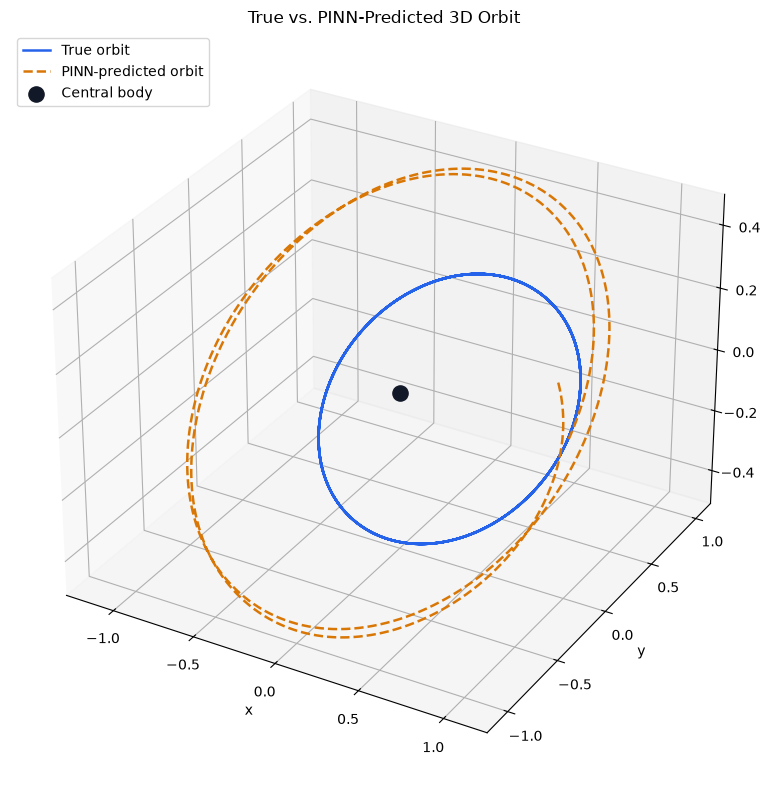

In [8]:
# Generates the 3D PINN's predicted trajectory and compares it against the true orbit
t_eval_tensor = torch.tensor(t_eval, dtype=torch.float32, device=device).reshape(-1, 1)

with torch.no_grad():
    pred_3d = pinn_3d(t_eval_tensor).cpu().numpy()

x_pinn_3d, y_pinn_3d, z_pinn_3d = pred_3d[:, 0], pred_3d[:, 1], pred_3d[:, 2]

errors_3d = np.sqrt((x_pinn_3d - x_true_3d)**2 + (y_pinn_3d - y_true_3d)**2 + (z_pinn_3d - z_true_3d)**2)
print(f"Average 3D position error: {errors_3d.mean():.4f}")
print(f"Max 3D position error: {errors_3d.max():.4f}")

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x_true_3d, y_true_3d, z_true_3d, color="#2563eb", linewidth=1.8, label="True orbit")
ax.plot(x_pinn_3d, y_pinn_3d, z_pinn_3d, color="#d97706", linewidth=1.8, linestyle="--", label="PINN-predicted orbit")
ax.scatter([0], [0], [0], color="#111827", s=120, label="Central body")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("True vs. PINN-Predicted 3D Orbit")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Step 6: A Real Camera Model

In Phase 2, converting between pixel space and world space was just a linear rescaling — flatten-and-stretch, no real optics involved. That worked because the camera was looking "straight down" at a flat 2D scene.

In 3D, we use an actual **pinhole camera model**: a simplified but genuine model of how real cameras work. A 3D point gets projected onto a 2D image plane by dividing by its distance from the camera (depth).

![Pinhole camera projection diagram](../images/pinhole_camera_concept.png)

The key formula:

**u = f × (x / z)**  and  **v = f × (y / z)**

where *f* is the focal length, and (x, y, z) is the satellite's true position relative to the camera. That division by *z* is the mathematical reason depth gets lost — it's a many-to-one mapping. Multiply a point's entire position by 2 (push it twice as far away) and its pixel position doesn't change at all.

In [11]:
# Defines the pinhole camera projection: converts a 3D world position into a 2D pixel position
focal_length = 145.0   # reduced from 300 so the full orbit fits inside the image frame
image_size = 64         # same resolution as the Phase 2 telescope images

# Center the camera on the orbit's average position (not just the origin), so the
# satellite doesn't drift off the edge of the frame as it moves through its elliptical path
camera_position = np.array([
    (x_true_3d.max() + x_true_3d.min()) / 2,
    (y_true_3d.max() + y_true_3d.min()) / 2,
    -4.0
])

def project_to_pixel(x, y, z, cam_pos=camera_position, f=focal_length, img_size=image_size):
    rel_x = x - cam_pos[0]
    rel_y = y - cam_pos[1]
    rel_z = z - cam_pos[2]   # "depth" — distance along the camera's viewing direction

    u = f * (rel_x / rel_z)
    v = f * (rel_y / rel_z)

    px = u + img_size / 2
    py = v + img_size / 2
    return px, py, rel_z

# Sanity check: project the true orbit and see where it lands in pixel space
px_true, py_true, depth_true = project_to_pixel(x_true_3d, y_true_3d, z_true_3d)
print(f"Pixel x range: {px_true.min():.1f} to {px_true.max():.1f}")
print(f"Pixel y range: {py_true.min():.1f} to {py_true.max():.1f}")
print(f"True depth range: {depth_true.min():.3f} to {depth_true.max():.3f}")

Pixel x range: 6.4 to 57.6
Pixel y range: 9.3 to 52.0
True depth range: 3.748 to 4.252


## Step 7: Generating Synthetic 3D Telescope Images

Same approach as Phase 2 — a 64×64 grayscale image with a soft Gaussian "dot" marking the satellite's projected position, plus realistic sensor noise. The only difference is that the dot's position now comes from real pinhole-camera projection instead of flat rescaling.

Generated 2000 telescope images of shape (64, 64)


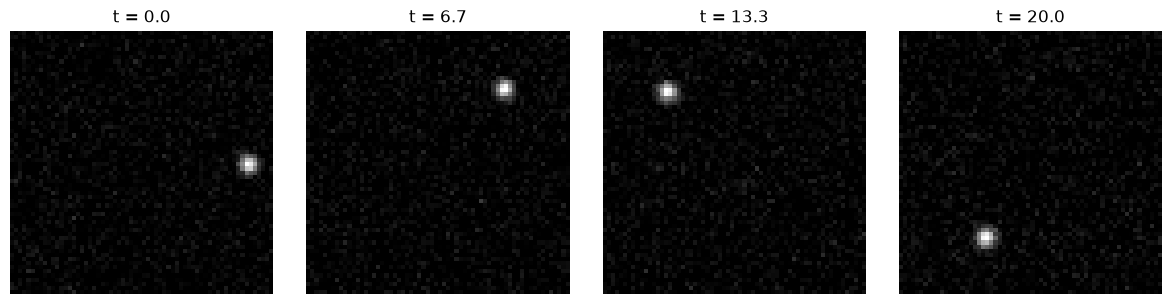

In [12]:
# Generates synthetic telescope images: a Gaussian blob at the satellite's projected
# pixel position, with added sensor noise, same style as Phase 2
def generate_telescope_image(px, py, img_size=64, blob_sigma=1.5, noise_std=0.05):
    yy, xx = np.meshgrid(np.arange(img_size), np.arange(img_size), indexing="ij")
    blob = np.exp(-((xx - px)**2 + (yy - py)**2) / (2 * blob_sigma**2))
    noise = np.random.normal(0, noise_std, size=blob.shape)
    image = np.clip(blob + noise, 0, 1)
    return image

# Generate one image per time step using the true projected positions
telescope_images_3d = np.array([
    generate_telescope_image(px_true[i], py_true[i]) for i in range(len(t_eval))
])

print(f"Generated {telescope_images_3d.shape[0]} telescope images of shape {telescope_images_3d.shape[1:]}")

# Preview a few sample frames
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
sample_indices = [0, len(t_eval)//3, 2*len(t_eval)//3, len(t_eval)-1]
for ax, idx in zip(axes, sample_indices):
    ax.imshow(telescope_images_3d[idx], cmap="gray")
    ax.set_title(f"t = {t_eval[idx]:.1f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 8: Detecting the Satellite in Each Image

Same CNN architecture as Phase 2 — it doesn't need to change at all, since it's just learning to regress a 2D pixel position from a 2D image. The only difference is what it's trained on: images generated by a real camera projection instead of flat rescaling.

In [13]:
# Defines the CNN detector: identical architecture to Phase 2, since the task is still
# "find the (px, py) pixel position of the bright dot in a 64x64 grayscale image"
class SatelliteDetector3D(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 16 * 16, 64), nn.ReLU(),
            nn.Linear(64, 2)  # outputs (px, py)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [15]:
# Safety checkpoint: save the trained 3D PINN so we never have to redo the 40,000-epoch training
torch.save(pinn_3d.state_dict(), "pinn_3d_weights.pth")
print("3D PINN weights saved.")

3D PINN weights saved.


In [17]:
# Trains the CNN detector on the synthetic 3D telescope images, with per-epoch timing
# so we can see exactly how fast (or slow) each step actually is
import time

images_tensor = torch.tensor(telescope_images_3d, dtype=torch.float32).unsqueeze(1)
targets_tensor = torch.tensor(np.stack([px_true, py_true], axis=1), dtype=torch.float32)

print("images_tensor shape:", images_tensor.shape)
print("targets_tensor shape:", targets_tensor.shape)
print("device:", device)

detector_3d = SatelliteDetector3D().to(device)
images_tensor, targets_tensor = images_tensor.to(device), targets_tensor.to(device)

optimizer = torch.optim.Adam(detector_3d.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

n_epochs = 400
start = time.time()
for epoch in range(n_epochs):
    optimizer.zero_grad()
    preds = detector_3d(images_tensor)
    loss = loss_fn(preds, targets_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        elapsed = time.time() - start
        print(f"Epoch {epoch:5d} | Pixel MSE: {loss.item():.4f} | Elapsed: {elapsed:.1f}s")

print("CNN detector training complete.")
torch.save(detector_3d.state_dict(), "detector_3d_weights.pth")

images_tensor shape: torch.Size([2000, 1, 64, 64])
targets_tensor shape: torch.Size([2000, 2])
device: cpu
Epoch     0 | Pixel MSE: 1500.6959 | Elapsed: 3.1s
Epoch    50 | Pixel MSE: 254.0639 | Elapsed: 66.9s
Epoch   100 | Pixel MSE: 113.3647 | Elapsed: 131.7s
Epoch   150 | Pixel MSE: 0.9146 | Elapsed: 197.8s
Epoch   200 | Pixel MSE: 0.5667 | Elapsed: 268.6s
Epoch   250 | Pixel MSE: 0.4717 | Elapsed: 331.3s
Epoch   300 | Pixel MSE: 0.4076 | Elapsed: 403.8s
Epoch   350 | Pixel MSE: 0.3637 | Elapsed: 468.1s
CNN detector training complete.


## Step 9: Checking the Detector's Accuracy

Before using this detector's output as a measurement in the Kalman filter, let's confirm what it's actually predicting — comparing its guessed pixel positions against the true ones, and visualizing where the errors are largest.

Average pixel error: 0.6840
Max pixel error: 2.9286


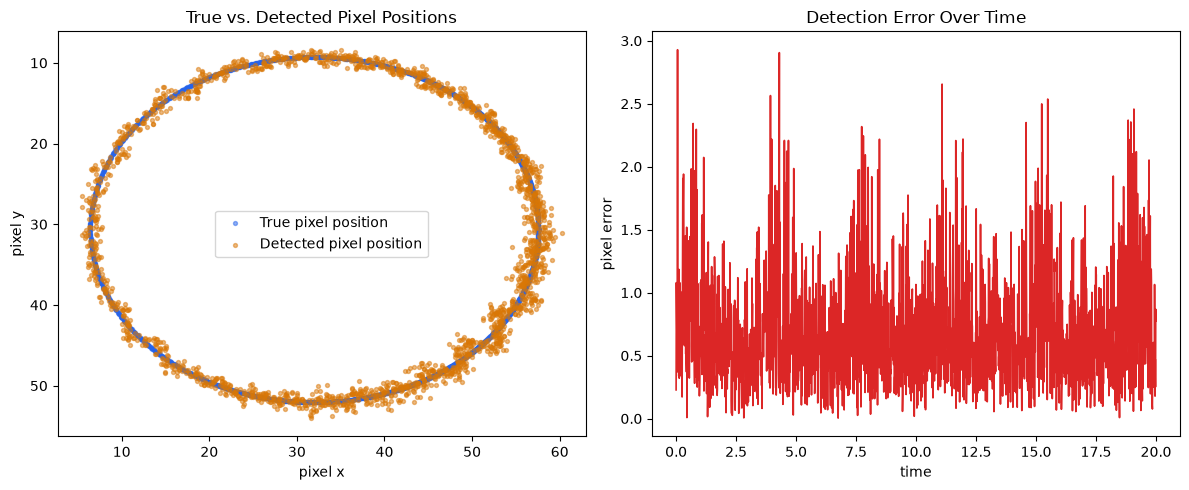

In [18]:
# Runs the trained detector on every telescope image and compares predictions to ground truth
with torch.no_grad():
    detected_pixels = detector_3d(images_tensor).cpu().numpy()

detected_px, detected_py = detected_pixels[:, 0], detected_pixels[:, 1]

pixel_errors = np.sqrt((detected_px - px_true)**2 + (detected_py - py_true)**2)
print(f"Average pixel error: {pixel_errors.mean():.4f}")
print(f"Max pixel error: {pixel_errors.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(px_true, py_true, s=8, color="#2563eb", alpha=0.5, label="True pixel position")
axes[0].scatter(detected_px, detected_py, s=8, color="#d97706", alpha=0.5, label="Detected pixel position")
axes[0].set_title("True vs. Detected Pixel Positions")
axes[0].set_xlabel("pixel x")
axes[0].set_ylabel("pixel y")
axes[0].legend()
axes[0].invert_yaxis()

axes[1].plot(t_eval, pixel_errors, color="#dc2626", linewidth=1.2)
axes[1].set_title("Detection Error Over Time")
axes[1].set_xlabel("time")
axes[1].set_ylabel("pixel error")

plt.tight_layout()
plt.show()

## Step 10: A Nonlinear Measurement Model

In Phase 3, the measurement model was simple: the vision system observed (x, y) directly, so H was just a constant matrix. That's why Phase 3's "Extended" Kalman Filter didn't actually need to be extended — a plain linear Kalman Filter would have worked identically.

This time it's different. The vision system observes a *pixel* (px, py), not a world position — and the relationship between a 3D state and a 2D pixel is the nonlinear projection from Step 6 (dividing by depth). The EKF's measurement model is literally that projection function, and the Jacobian needed to linearize it changes at every single time step, because the satellite's depth keeps changing as it orbits. This is a real, necessary use of the "Extended" part of EKF.

In [19]:
# Defines the nonlinear measurement model: projects a 6D state (x,y,z,vx,vy,vz)
# into a predicted 2D pixel position, using the same pinhole camera math as Step 6
cam_pos_tensor = torch.tensor(camera_position, dtype=torch.float32)
f_tensor = torch.tensor(focal_length, dtype=torch.float32)
img_size_tensor = torch.tensor(float(image_size))

def measurement_model(state, cam_pos=cam_pos_tensor, f=f_tensor, img_size=img_size_tensor):
    x, y, z = state[0], state[1], state[2]
    rel_x = x - cam_pos[0]
    rel_y = y - cam_pos[1]
    rel_z = z - cam_pos[2]

    u = f * (rel_x / rel_z)
    v = f * (rel_y / rel_z)

    px = u + img_size / 2
    py = v + img_size / 2
    return torch.stack([px, py])

# Sanity check: measurement model applied to the true initial state should match
# the true initial pixel position we computed back in Step 6
test_state = torch.tensor(initial_state_3d, dtype=torch.float32)
predicted_pixel = measurement_model(test_state)
print("Predicted pixel from measurement model:", predicted_pixel.detach().numpy())
print("True pixel at t=0 (for comparison):", px_true[0], py_true[0])

Predicted pixel from measurement model: [57.52816  31.999994]
True pixel at t=0 (for comparison): 57.52816317114245 31.999994982239148


## Step 11: The 3D Process Model

Same idea as Phase 3's predict step — integrate pure two-body gravity forward using RK4 — just with three position and three velocity components instead of two. The filter's internal physics model stays intentionally "dumb" (plain gravity, no PINN involved) exactly like Phase 3, since the whole point is to see the filter reconcile a simple physics prediction with noisy vision input.

In [20]:
# Defines the 3D process model (RK4-integrated two-body dynamics) and checks its Jacobian
def state_transition_3d(state, dt, GM=1.0):
    def dynamics(s):
        x, y, z, vx, vy, vz = s[0], s[1], s[2], s[3], s[4], s[5]
        r = torch.sqrt(x**2 + y**2 + z**2 + 1e-8)
        ax = -GM * x / r**3
        ay = -GM * y / r**3
        az = -GM * z / r**3
        return torch.stack([vx, vy, vz, ax, ay, az])

    k1 = dynamics(state)
    k2 = dynamics(state + dt / 2 * k1)
    k3 = dynamics(state + dt / 2 * k2)
    k4 = dynamics(state + dt * k3)
    return state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

test_state_3d = torch.tensor(initial_state_3d, dtype=torch.float32)
test_dt = 0.02
F_sample_3d = jacobian(lambda s: state_transition_3d(s, test_dt), test_state_3d)
print("Sample 3D state-transition Jacobian (F matrix), shape:", F_sample_3d.shape)
print(F_sample_3d)

Sample 3D state-transition Jacobian (F matrix), shape: torch.Size([6, 6])
tensor([[ 1.0004e+00,  2.8000e-06,  1.2000e-06,  2.0003e-02,  2.8002e-08,
          1.2001e-08],
        [ 2.8004e-06,  9.9980e-01,  8.4005e-09,  2.8002e-08,  1.9999e-02,
          8.4009e-11],
        [ 1.2002e-06,  8.4005e-09,  9.9980e-01,  1.2001e-08,  8.4009e-11,
          1.9999e-02],
        [ 4.0004e-02,  4.2002e-04,  1.8001e-04,  1.0004e+00,  5.6005e-06,
          2.4002e-06],
        [ 4.2010e-04, -1.9996e-02,  1.6803e-06,  5.6009e-06,  9.9980e-01,
          2.5205e-08],
        [ 1.8004e-04,  1.6803e-06, -2.0000e-02,  2.4004e-06,  2.5205e-08,
          9.9980e-01]])


## Step 12: Measurement Noise and Process Noise

R (measurement noise) is estimated the same way as Phase 3 — empirically, from the actual residual variance between the detector's predictions and the true pixel positions, rather than guessed.

Q (process noise) reflects how much we trust the "dumb" physics-only process model between measurements. Since this model has no idea about any real-world disturbance, we give it some slack — especially on velocity, which is where unmodeled forces would first show up.

In [21]:
# Measurement noise R: estimated from the actual detector error (reusing pixel_errors from Step 9)
pixel_error_x = detected_px - px_true
pixel_error_y = detected_py - py_true
R = np.diag([np.var(pixel_error_x), np.var(pixel_error_y)])
print("R (measurement noise):")
print(R)

# Process noise Q: tunable, larger on velocity components since the process model
# doesn't account for any disturbance
Q = np.diag([1e-5, 1e-5, 1e-5, 1e-3, 1e-3, 1e-3])
print("\nQ (process noise):")
print(Q)

R (measurement noise):
[[0.40298843 0.        ]
 [0.         0.26301078]]

Q (process noise):
[[1.e-05 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e-05 0.e+00 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 1.e-05 0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 1.e-03 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 1.e-03 0.e+00]
 [0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 1.e-03]]


## Step 13: The Full 3D Extended Kalman Filter

Same predict/correct cycle as Phase 3, but now two things are genuinely nonlinear and re-linearized at every single time step: the process model (same as before) and, new this time, the measurement model — because projecting the predicted 3D state into a pixel position depends on the satellite's current depth, which keeps changing.

In [22]:
# Runs the full 3D Extended Kalman Filter: predicts with gravity-only dynamics,
# corrects using the CNN detector's pixel observations via the nonlinear camera projection
state_est = np.array(initial_state_3d, dtype=np.float64)
P = np.eye(6) * 1e-6

x_ekf_3d = np.zeros(len(t_eval))
y_ekf_3d = np.zeros(len(t_eval))
z_ekf_3d = np.zeros(len(t_eval))
x_ekf_3d[0], y_ekf_3d[0], z_ekf_3d[0] = state_est[0], state_est[1], state_est[2]

for i in range(1, len(t_eval)):
    dt = t_eval[i] - t_eval[i - 1]

    # ---- Predict ----
    state_tensor = torch.tensor(state_est, dtype=torch.float32)
    state_pred_tensor = state_transition_3d(state_tensor, dt, GM=GM)
    F_tensor = jacobian(lambda s: state_transition_3d(s, dt, GM=GM), state_tensor)
    state_pred = state_pred_tensor.detach().numpy()
    F = F_tensor.detach().numpy()
    P_pred = F @ P @ F.T + Q

    # ---- Correct ----
    state_pred_tensor2 = torch.tensor(state_pred, dtype=torch.float32)
    h_pred_tensor = measurement_model(state_pred_tensor2)
    H_tensor = jacobian(measurement_model, state_pred_tensor2)
    h_pred = h_pred_tensor.detach().numpy()
    H = H_tensor.detach().numpy()

    z = np.array([detected_px[i], detected_py[i]])
    y_residual = z - h_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    state_est = state_pred + K @ y_residual
    P = (np.eye(6) - K @ H) @ P_pred

    x_ekf_3d[i], y_ekf_3d[i], z_ekf_3d[i] = state_est[0], state_est[1], state_est[2]

print("3D EKF run complete.")

3D EKF run complete.


## Step 14: Final Comparison — True vs. PINN-Only vs. EKF-Fused

The moment of truth: does fusing the physics-only prediction with bearing-only vision observations, through a nonlinear EKF, actually pull the estimate back toward the true 3D orbit?

Average PINN-only 3D error: 1.2243
Average EKF-fused 3D error: 0.0660
Max PINN-only 3D error: 2.0971
Max EKF-fused 3D error: 0.4974


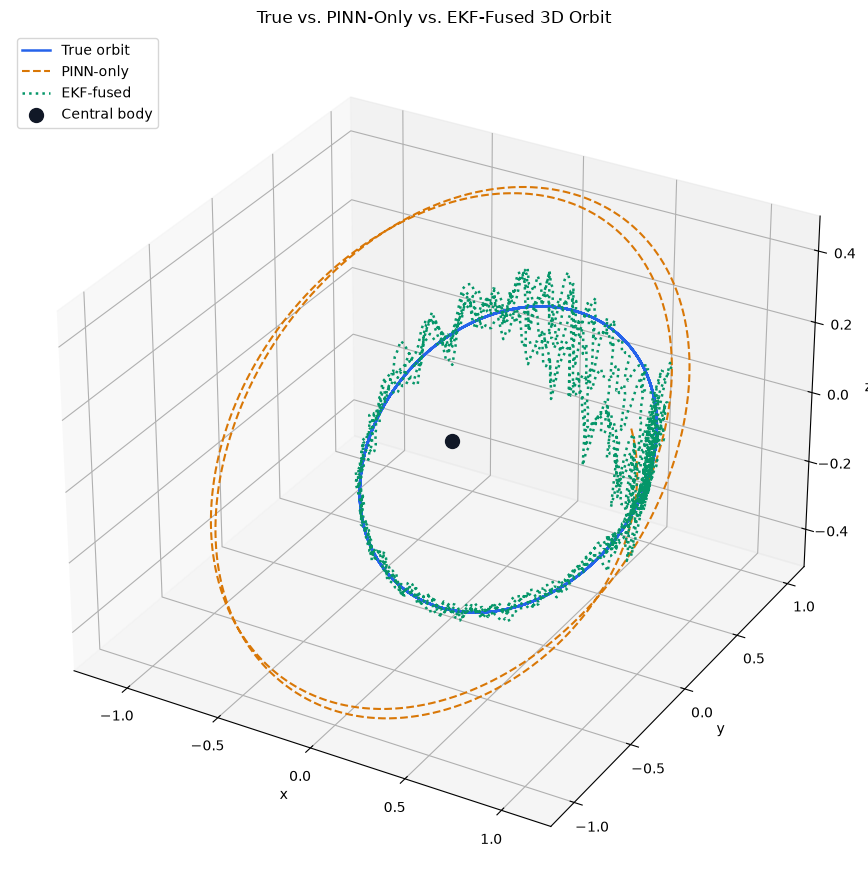

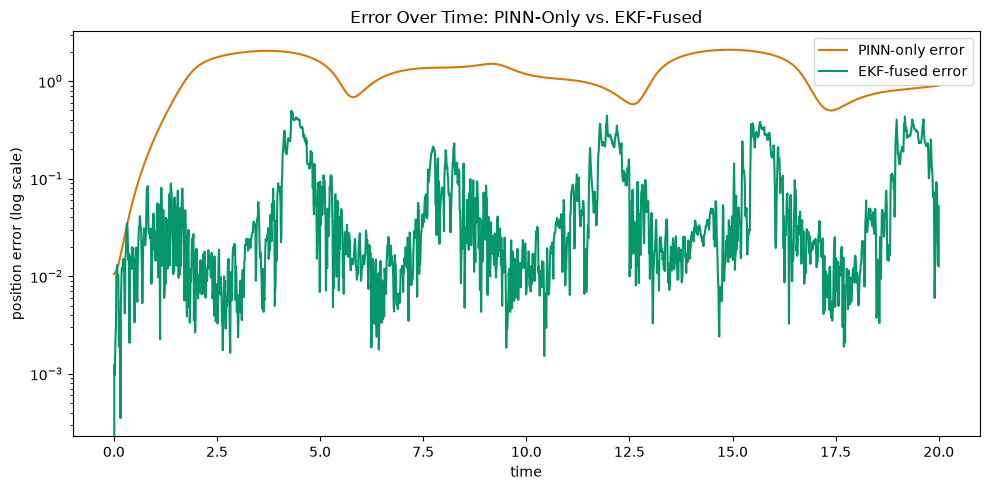

In [24]:
# Computes final error metrics and visualizes true vs. PINN-only vs. EKF-fused 3D orbits
errors_ekf_3d = np.sqrt((x_ekf_3d - x_true_3d)**2 + (y_ekf_3d - y_true_3d)**2 + (z_ekf_3d - z_true_3d)**2)

print(f"Average PINN-only 3D error: {errors_3d.mean():.4f}")
print(f"Average EKF-fused 3D error: {errors_ekf_3d.mean():.4f}")
print(f"Max PINN-only 3D error: {errors_3d.max():.4f}")
print(f"Max EKF-fused 3D error: {errors_ekf_3d.max():.4f}")

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x_true_3d, y_true_3d, z_true_3d, color="#2563eb", linewidth=1.8, label="True orbit")
ax.plot(x_pinn_3d, y_pinn_3d, z_pinn_3d, color="#d97706", linewidth=1.5, linestyle="--", label="PINN-only")
ax.plot(x_ekf_3d, y_ekf_3d, z_ekf_3d, color="#059669", linewidth=1.8, linestyle=":", label="EKF-fused")
ax.scatter([0], [0], [0], color="#111827", s=100, label="Central body")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("True vs. PINN-Only vs. EKF-Fused 3D Orbit")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Error-over-time comparison
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(t_eval, errors_3d, color="#d97706", label="PINN-only error")
ax2.plot(t_eval, errors_ekf_3d, color="#059669", label="EKF-fused error")
ax2.set_yscale("log")
ax2.set_xlabel("time")
ax2.set_ylabel("position error (log scale)")
ax2.set_title("Error Over Time: PINN-Only vs. EKF-Fused")
ax2.legend()
plt.tight_layout()
plt.show()

## Summary

This phase took the project into three dimensions and, with it, into genuinely harder territory than Phases 1–3: a single telescope image doesn't give a full 3D position, only a direction. Resolving that ambiguity required an Extended Kalman Filter whose "Extended" part was doing real work — both the physics process model and the camera measurement model are nonlinear, and both get re-linearized at every time step.

![Phase 4 results: PINN-only vs. EKF-fused 3D position error](../images/phase4_results_chart.png)

The result: average 3D position error dropped from 1.2243 (physics alone) to 0.0660 with bearing-only vision fusion — a ~95% reduction — using nothing but a direction to the satellite and a simple two-body gravity model that doesn't even know a neural network exists. The remaining error isn't noise to be eliminated; it's the honest signature of depth uncertainty in monocular (single-camera) tracking, visible as jitter along the line of sight in the 3D plot above.

This mirrors the real constraint ground-based satellite tracking faces: a single telescope can't triangulate depth on its own, so every real system either uses multiple stations, external range data (radar), or — as demonstrated here — a physics prior to fill the gap. Four phases in, the project's throughline holds: physics and vision are each individually incomplete, and the right way to combine them is a principled estimator that knows how much to trust each one, not a fixed rule.